In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
register_matplotlib_converters()
from time import time
import matplotlib.pyplot as plt
from warnings import filters
import jax.numpy as jnp
import jax
from caskade import Param, forward
import numpy as np
import pandas as pd
from tinygp import GaussianProcess, kernels
import jaxopt
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import math 

In [40]:
# TODO: Look at interplay between GP params, wavelength and redshift. 
# copy-pasted from tiny_gp_experiments.ipynb:

passband_group = PassbandGroup.from_preset(
    preset="LSST",
)
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",
)

#chekc out https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/agn.html#AGN-Damped-Random-Walk-Example

lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)

#I'll just keep this instead of caskade because I'm only gathering some preliminaruy data, will not have it written in final code
bh_mass = FunctionNode(
    lambda lg_mass: 10**lg_mass,
    lg_mass=lg_bh_mass,
    node_label="bh_mass",
)


def edd_ratio_pdf(value):
    xi = 10**-1.65
    lambda_br = 10**-1.84
    delta1 = 0.471 - 0.7
    delta2 = 2.53
    min_lambda = 0.01
    max_lambda = 1.0
    value = np.asarray(value)
    fill_mask = (value >= min_lambda) & (value <= max_lambda)
    prob = np.zeros_like(value)
    prob[fill_mask] = xi / (
        (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
    )
    return prob

edd_ratio = SamplePDF(edd_ratio_pdf)

radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

bh_mass = 1e8
edd_ratio = 0.25

model = AGN(
    t0=obstable.time_bounds()[0],
    redshift=0.1,
    cosmology=Planck18,
    passband_group=passband_group,
    redshift_dist_func=0,
    blackhole_mass=bh_mass,
    ra=radec.ra,
    dec=radec.dec,
    edd_ratio=edd_ratio,
)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

rng = np.random.default_rng(501)

n = 1

df = simulate_lightcurves(
    model=model,
    num_samples=n,
    survey_info=survey_info,
    # param_cols=[
    #     "bh_mass.lg_mass",
    #     "AGN_0.edd_ratio"
    # ],       
    rng=rng)

Simulating: 100%|██████████| 1/1 [00:00<00:00,  6.34obj/s]


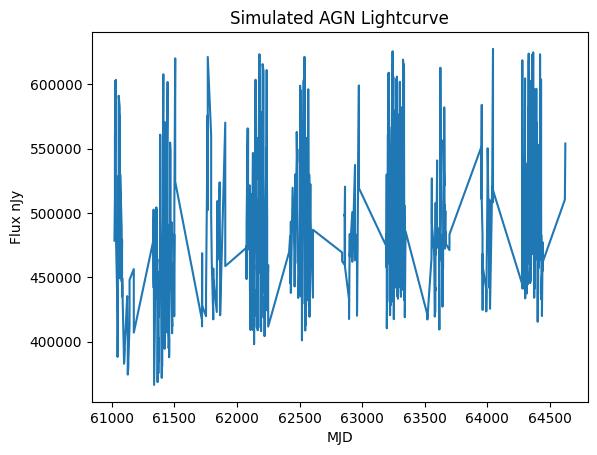

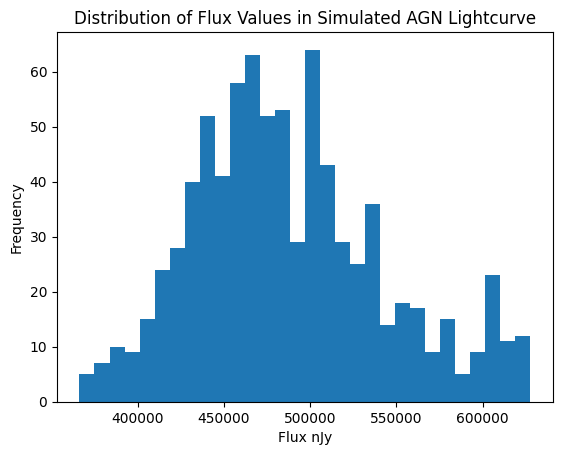

3.7293272769384203
0.024067988124443218


In [41]:



lightcurve = df.loc[0, "lightcurve"]
if lightcurve is None or "flux_perfect" not in lightcurve.columns:
    print(f"Warning: Sample {i} has no lightcurve data or missing 'flux_perfect' column. Skipping.")
sample_data = pd.DataFrame(lightcurve)[["mjd", "flux_perfect"]]
x = sample_data.loc[:, "mjd"]
y = sample_data.loc[:, "flux_perfect"]


plt.plot(x, y)
plt.xlabel("MJD")
plt.ylabel("Flux nJy")
plt.title("Simulated AGN Lightcurve")
plt.show()

plt.hist(y, bins=30)
plt.xlabel("Flux nJy")
plt.ylabel("Frequency")
plt.title("Distribution of Flux Values in Simulated AGN Lightcurve")
plt.show()


print(x[1] - x[0])
print(x[2] - x[1])



[ 1.00000000e+00 -2.41345280e-02  8.23381217e-02 -2.42638539e-02
  1.23698997e-02  3.54771754e-03  6.79074290e-03  5.67609155e-05
  7.43436494e-03 -1.43462139e-02  6.72123674e-03  1.36175876e-02
  1.57661275e-02 -1.28412579e-02  3.05630436e-02 -1.16399078e-02
 -4.08054163e-03 -1.48630255e-02  3.34994222e-03  4.07595955e-03
  6.26619122e-04  9.98739821e-02  6.41037127e-04 -3.06653418e-03
  7.89391863e-03 -2.07763404e-02  1.30901354e-01 -1.80231085e-03
 -1.39777997e-03  6.82565568e-02]


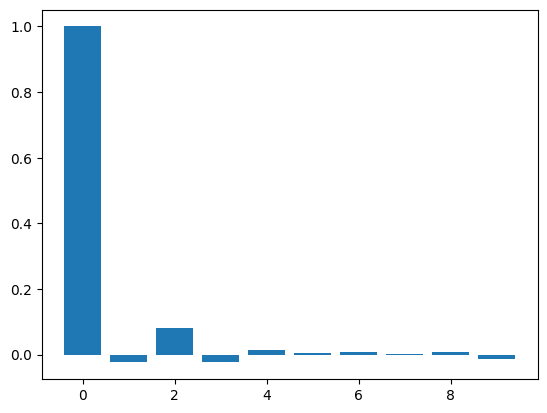

In [42]:
first_diff = x.diff()
first_diff = first_diff[1:]
acf_vals = acf(first_diff)
print(acf_vals)
num_lags = 10
plt.bar(range(num_lags), acf_vals[:num_lags])
plt.show()

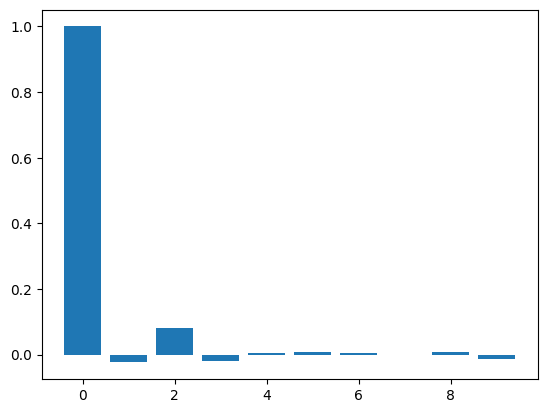

In [43]:
pacf_vals = pacf(first_diff)
plt.bar(range(num_lags), pacf_vals[:num_lags])
plt.show()

Based on these plots, w'll make an ARMA(1,1) plot, at least to begin with. In the reference code I found the ARMA model is trained on the first difference, so I will do the same. Note that this assumes uniform cadence, which is not a valid assumption in our case, but I will generalize it later. 

In [44]:
model = ARIMA(first_diff, order=(1, 1, 0), seasonal_order=(0, 0, 0, 0))
start = time()
model_fit = model.fit()
end = time()
print('Model Fitting Time:', end - start)
model_fit.summary()

Model Fitting Time: 0.02896428108215332


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    mjd   No. Observations:                  815
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -3820.202
Date:                Fri, 05 Jun 2026   AIC                           7644.403
Time:                        14:28:33   BIC                           7653.807
Sample:                             0   HQIC                          7648.013
                                - 815                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5719      0.008    -75.057      0.000      -0.587      -0.557
sigma2       697.7553      7.454     93.603      0.000     683.145     712.366
===================================================================================
Ljung-Box (L1) (Q):                  21.01   Jarque-Bera (JB):             58942.16
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.72   Skew:                             3.64
Prob(H) (two-sided):                  0.00   Kurtosis:                        44.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

So our model is:
y_t = -0.57y_(t-1) + 0.52eps_t

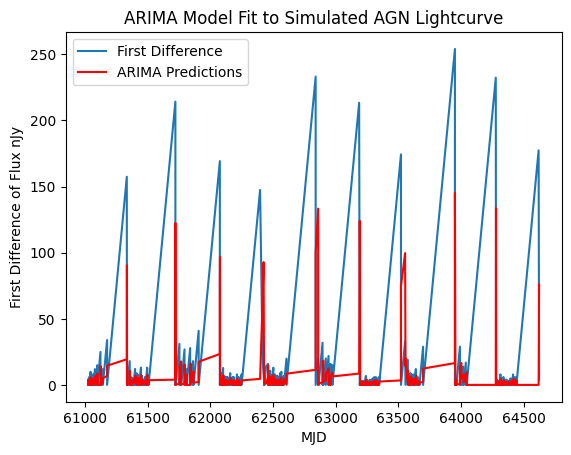

In [45]:
predictions = model_fit.predict(start=0, end=len(first_diff)-1)
plt.plot(x[1:], first_diff, label='First Difference')
plt.plot(x[1:], predictions, label='ARIMA Predictions', color='red')
plt.xlabel("MJD")
plt.ylabel("First Difference of Flux nJy")
plt.title("ARIMA Model Fit to Simulated AGN Lightcurve")
plt.legend()
plt.show()

Model Fitting Time: 0.0385441780090332


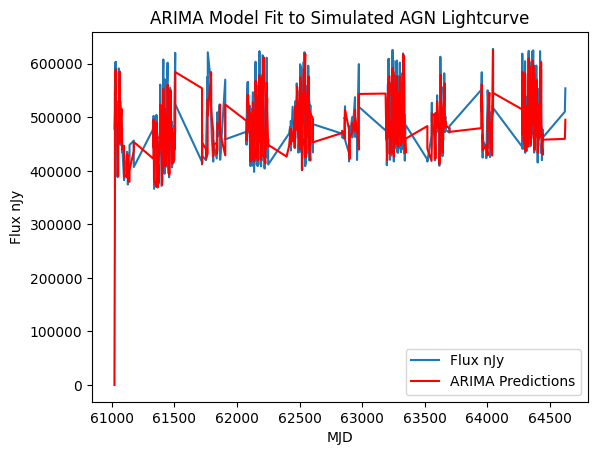

In [46]:
model = ARIMA(y, order=(1, 1, 0), seasonal_order=(0, 0, 0, 0))
start = time()
model_fit = model.fit()
end = time()
print('Model Fitting Time:', end - start)
model_fit.summary()
predictions = model_fit.predict(start=0, end=len(x)-1)
plt.plot(x, y, label='Flux nJy')
plt.plot(x, predictions, label='ARIMA Predictions', color='red')
plt.xlabel("MJD")
plt.ylabel("Flux nJy")
plt.title("ARIMA Model Fit to Simulated AGN Lightcurve")
plt.legend()
plt.show()

In [47]:
print(model_fit.summary())
print(model_fit.params)
print(type(model_fit.params))

                               SARIMAX Results                                
Dep. Variable:           flux_perfect   No. Observations:                  816
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -9987.270
Date:                Fri, 05 Jun 2026   AIC                          19978.541
Time:                        14:28:33   BIC                          19987.947
Sample:                             0   HQIC                         19982.151
                                - 816                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3111      0.022    -14.147      0.000      -0.354      -0.268
sigma2      2.537e+09   6.77e-13   3.75e+21      0.000    2.54e+09    2.54e+09
Ljung-Box (L1) (Q):                   7.12   Jarque-

Model Fitting Time: 0.03439664840698242


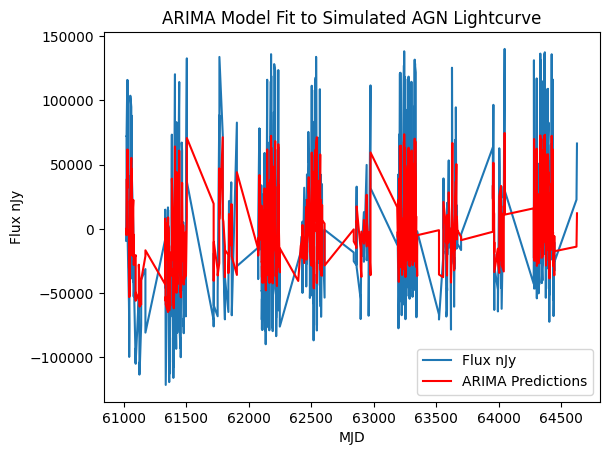

                               SARIMAX Results                                
Dep. Variable:           flux_perfect   No. Observations:                  816
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -9936.795
Date:                Fri, 05 Jun 2026   AIC                          19879.590
Time:                        14:28:33   BIC                          19893.703
Sample:                             0   HQIC                         19885.007
                                - 816                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.131e-08   3530.151   8.87e-12      1.000   -6918.970    6918.970
ar.L1          0.5329      0.030     17.701      0.000       0.474       0.592
sigma2      2.213e+09      0.064   3.47e+10      0.0

In [48]:
y_standard = y - np.mean(y)
model = ARIMA(y_standard, order=(1, 0, 0), seasonal_order=(0, 0, 0, 0))
start = time()
model_fit = model.fit()
end = time()
print('Model Fitting Time:', end - start)
predictions = model_fit.predict(start=0, end=len(x)-1)
plt.plot(x, y_standard, label='Flux nJy')
plt.plot(x, predictions, label='ARIMA Predictions', color='red')
plt.xlabel("MJD")
plt.ylabel("Flux nJy")
plt.title("ARIMA Model Fit to Simulated AGN Lightcurve")
plt.legend()
plt.show()

print(model_fit.summary())

params = model_fit.params
print(params)

To avoid last time's mistakes, I will check two things:
1 - I can initialize a full model with those simply learned parameters
2- Once I have a full mdoel, I can easily get its prediction at a certain time

In [49]:

def get_arima_predictions(x0, t0, query_time, ar_coef):
    """Get the predicted value at query_time using an ARIMA(1,0,0) model with the given AR and MA coefficients.
    Precondition: t0 and query_time are in MJD.
    """
    time_diff = query_time - t0
    if time_diff < 0:
        raise ValueError("query_time must be greater than or equal to t0")
    if time_diff == 0:
        return x0
    if time_diff <= 1:
        white_noise = np.random.normal(0, np.sqrt(2.213e+09))  # Assume white noise with mean 0 and std 1
        x1 = ar_coef * x0 + white_noise
        if time_diff == 1:
            return x1
        else:
            return (x0 + x1) / 2  # Linear interpolation for intermediate time
    else:
        return get_arima_predictions(get_arima_predictions(x0, t0, t0 + 1, ar_coef), t0 + 1, query_time, ar_coef)


def get_arima_chain(x0, num_steps, ar_coef, sigma=2.213e+09):
    """Get the predicted value at query_time using an ARIMA(1,0,0) model with the given AR and MA coefficients.
    """
    lst = [x0]
    for _ in range(num_steps):
        white_noise = np.random.normal(0, np.sqrt(sigma))  # Assume white noise with mean 0 and std 1
        x_next = ar_coef * lst[-1] + white_noise
        lst.append(x_next)
    return lst
        

[np.float64(547450.8023013012), np.float64(282972.299557962), np.float64(193892.2562209994), np.float64(123520.54468043608), np.float64(79991.43120995071), np.float64(61673.14763737134), np.float64(61061.810536915684), np.float64(-55373.95888437121), np.float64(-43142.526503028), np.float64(-38346.70774147209), np.float64(-4245.4288434655955), np.float64(17754.803335645694), np.float64(21492.04291406921), np.float64(19277.72339684057), np.float64(95033.84726050196), np.float64(49658.91606840655), np.float64(83996.88717784788), np.float64(59577.44570680734), np.float64(82668.91467245195), np.float64(-27953.527387367285), np.float64(-59383.28988245713), np.float64(-109486.55315437716), np.float64(-81174.1043253399), np.float64(-78072.8352090113), np.float64(-6868.181571915316), np.float64(-32815.284333715164), np.float64(-49414.992590921844), np.float64(-21543.149720717964), np.float64(-24634.229434733024), np.float64(11324.017063389814), np.float64(24922.720988793655), np.float64(-46538

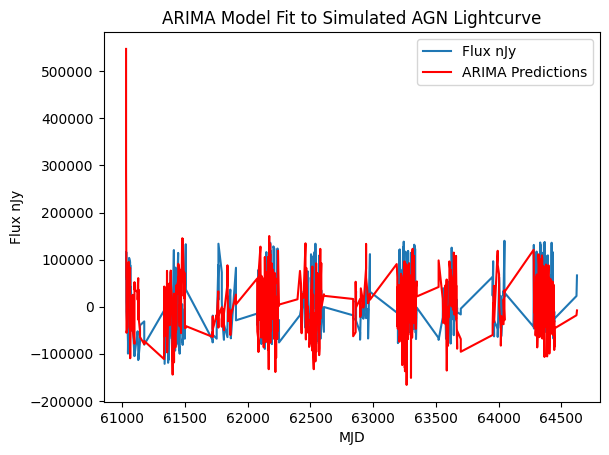

In [50]:

predictions = get_arima_chain(y[5], len(x)-5,  0.5329)
print(predictions)

plt.plot(x[4:], y_standard[4:], label='Flux nJy')
plt.plot(x[4:], predictions, label='ARIMA Predictions', color='red')
plt.xlabel("MJD")
plt.ylabel("Flux nJy")
plt.title("ARIMA Model Fit to Simulated AGN Lightcurve")
plt.legend()
plt.show()

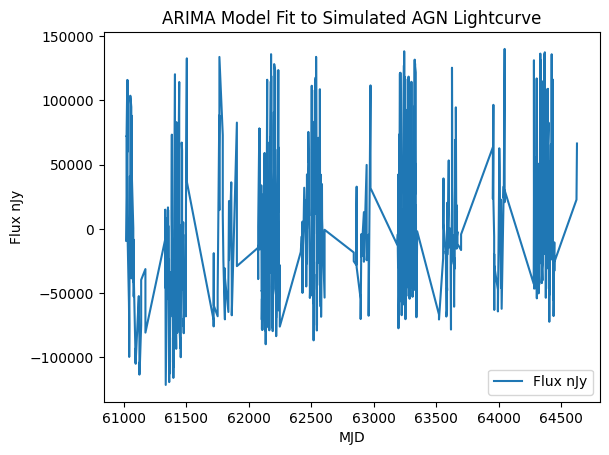

In [51]:
from statsmodels.tsa.arima_process import ArmaProcess

arparams = np.array([0.5329])
ar = np.r_[1, -arparams] 
model2 = ArmaProcess(ar=ar, ma=[1])

plt.plot(x, y_standard, label='Flux nJy')
plt.xlabel("MJD")
plt.ylabel("Flux nJy")
plt.title("ARIMA Model Fit to Simulated AGN Lightcurve")
plt.legend()
plt.show()





# First draft !

EVERYTHING BEFORE NOW WAS BAD BECAUSE IT ASSUMED UNIFORM CADENCE EVEN THOUGH OUR SIMULATIONS DIDNT HAVE THAT!!!

In [52]:
from scipy.stats import chi2
chi_params = chi2.fit(y)
print(chi_params)


(np.float64(0.00010939172211224131), np.float64(400994.46463735995), np.float64(2.777065051432885))


In [53]:
print(np.mean(y))

band = "r"
cadence_days = 10
n = 1000

t_start = obstable.time_bounds()[0]
t_end = t_start + cadence_days * n

all_times = np.arange(t_start, t_end, cadence_days)
n_obs = len(all_times)
print(f"Number of observations: {n_obs}")

survey_data = {
    "observationStartMJD": all_times,
    "fieldRA":             np.full(n_obs, 30),
    "fieldDec":            np.full(n_obs, 30),
    "filter":              [band] * n_obs,
    "zp_nJy":             np.ones(n_obs),
    "seeing":              np.full(n_obs, 0.7),
    "skybrightness":       np.full(n_obs, 20.0),
    "exptime":             np.full(n_obs, 30.0),
    "nexposure":           np.full(n_obs, 2),
}

uniform_obstable = OpSim(survey_data)
survey_info = SurveyInfo(obstable=uniform_obstable, passband_group=passband_group)

487699.8024323594
Number of observations: 1000


In [54]:

bh_mass = 1e8
edd_ratio = 0.25

model = AGN(
    t0=obstable.time_bounds()[0],
    redshift=0.1,
    cosmology=Planck18,
    passband_group=passband_group,
    redshift_dist_func=0,
    blackhole_mass=bh_mass,
    ra=30,
    dec=30,
    edd_ratio=edd_ratio,
)


rng = np.random.default_rng(501)

ds = simulate_lightcurves(
    model=model,
    num_samples=n,
    survey_info=survey_info,     
    rng=rng)

print(ds)



Simulating: 100%|██████████| 1000/1000 [00:36<00:00, 27.59obj/s]


      id  ...                                             params
0      0  ...  {'AGN_0.ra': 30, 'AGN_0.dec': 30, 'AGN_0.redsh...
1      1  ...  {'AGN_0.ra': 30, 'AGN_0.dec': 30, 'AGN_0.redsh...
..   ...  ...                                                ...
998  998  ...  {'AGN_0.ra': 30, 'AGN_0.dec': 30, 'AGN_0.redsh...
999  999  ...  {'AGN_0.ra': 30, 'AGN_0.dec': 30, 'AGN_0.redsh...

[1000 rows x 8 columns]


In [55]:
def get_arima_chain(x0, t0, num_steps, ar_coef, sigma, c, cadence_days):
    """Get the predicted value at query_time using an ARIMA(1,0,0) model with the given AR and MA coefficients.
    """
    times = np.arange(num_steps + 1) * cadence_days + t0
    lst = [x0]
    for _ in range(num_steps):
        white_noise = np.random.normal(0, np.sqrt(sigma)) # Assume white noise is normal
        x_next = ar_coef * lst[-1] + white_noise + c
        lst.append(x_next)
    return lst, times

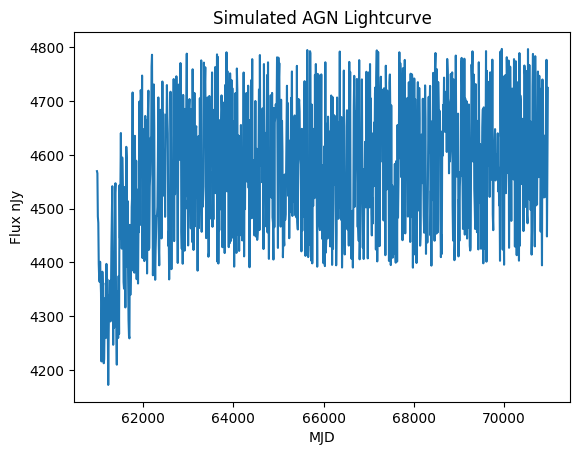

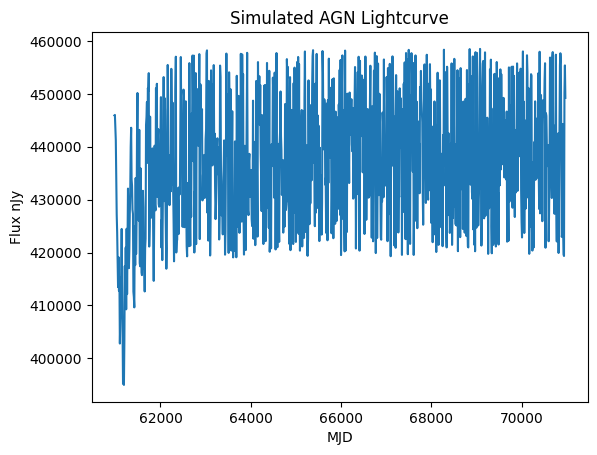

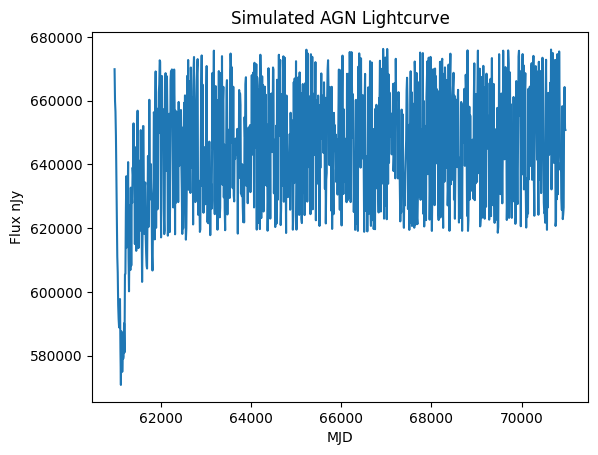

              0              1     ...           999            1000
0      4215.688315    5655.313690  ...    5832.847211    5691.496450
1    412770.598044  510413.510428  ...  521627.740896  504162.228947
..             ...            ...  ...            ...            ...
998  581550.010183  644515.144534  ...  674359.379413  696183.478244
999  544079.700933  765873.375787  ...  814154.416567  815338.333082

[1000 rows x 1001 columns]
            0              1     ...           999            1000
0    4215.688315    5655.313690  ...    5832.847211    5691.496450
1  412770.598044  510413.510428  ...  521627.740896  504162.228947
2  588847.998702  742316.742565  ...  820029.490716  829891.135995
3  482328.555725  597367.218997  ...  610885.531265  632746.183433
4  159518.323932  212239.175821  ...  232829.118783  246462.758433

[5 rows x 1001 columns]


In [56]:

for i in range(n):
    lightcurve = ds.loc[i, "lightcurve"]
    if lightcurve is None or "flux_perfect" not in lightcurve.columns:
        print(f"Warning: Sample {i} has no lightcurve data or missing 'flux_perfect' column. Skipping.")
    sample_data = pd.DataFrame(lightcurve)[["mjd", "flux_perfect"]]
    x = sample_data.loc[:, "mjd"]
    y = sample_data.loc[:, "flux_perfect"] 
    model = ARIMA(y, order=(1, 0, 0), seasonal_order=(0, 0, 0, 0))
    model_fit = model.fit()
    predictions = model_fit.predict(start=0, end=len(x)-1)
    df = pd.concat([df, pd.DataFrame([model_fit.params])], ignore_index=True)

    if i <= 2:
        plt.plot(x, y)
        plt.xlabel("MJD")
        plt.ylabel("Flux nJy")
        plt.title("Simulated AGN Lightcurve")
        plt.show()

df.to_csv("arima_params.csv", index=False)

samples = []
for i in range(n):
    ar = df.loc[i+1, "ar.L1"]
    sigma = df.loc[i+1, "sigma2"]
    c = df.loc[i+1, "const"]
    p1, p2, p3 = chi_params
    x0 = ds.loc[i, "lightcurve"]["flux_perfect"].iloc[10]
    t0 = ds.loc[i, "lightcurve"]["mjd"].iloc[10]
    sample, times = get_arima_chain(x0, t0, n_obs,  ar, sigma, c, cadence_days) 
    for j in range(len(sample)):
        sample[j] = sample[j] 
    samples.append(sample)

samples = pd.DataFrame(samples)

print(samples)

samples = pd.DataFrame(samples)

print(samples.head())
    
samples.to_csv("arima_samples.csv", index=False)



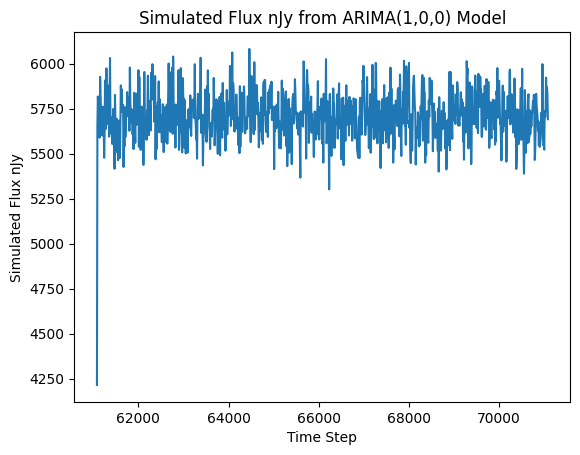

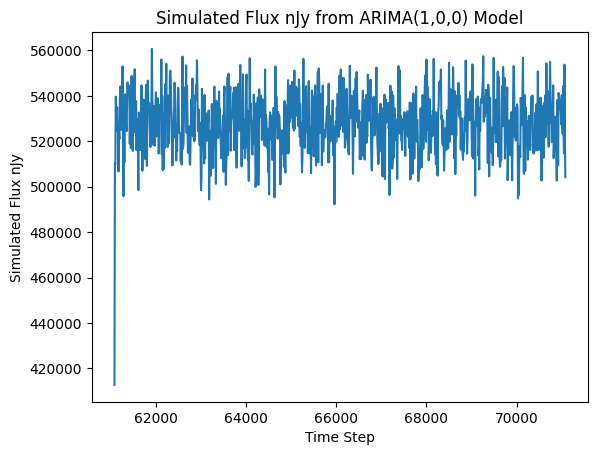

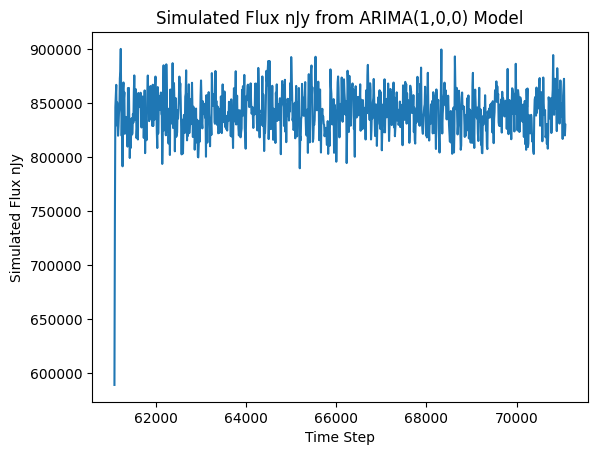

In [57]:
for i in range(3):
    plt.plot(times, samples.iloc[i])
    plt.xlabel("Time Step")
    plt.ylabel("Simulated Flux nJy")
    plt.title("Simulated Flux nJy from ARIMA(1,0,0) Model")
    plt.show()

In [58]:
print(df[["ar.L1", "sigma2"]].describe())
for i in range(5):
    lightcurve = ds.loc[i, "lightcurve"]
    y = lightcurve["flux_perfect"]
    print(f"Sample {i}: data_std={y.std():.4f}, data_mean={y.mean():.4f}")

print(df[["ar.L1", "sigma2"]].head())

             ar.L1        sigma2
count  1000.000000  1.000000e+03
mean      0.238894  2.582441e+08
std       0.049587  1.817406e+08
min       0.089823  7.941040e+02
25%       0.201896  7.625943e+07
50%       0.237997  2.651149e+08
75%       0.272372  4.347513e+08
max       0.386137  5.728056e+08
Sample 0: data_std=127.2364, data_mean=4570.6420
Sample 1: data_std=12122.5420, data_mean=437041.9471
Sample 2: data_std=18881.1252, data_mean=644537.9468
Sample 3: data_std=14619.3486, data_mean=519602.0113
Sample 4: data_std=5102.3103, data_mean=176032.0672
      ar.L1        sigma2
0       NaN           NaN
1  0.199320  1.554560e+04
2  0.174044  1.424271e+08
3  0.233398  3.364811e+08
4  0.186651  2.062715e+08


# Attempt Number 2, fixing statsmodels parameters :D, 1 AGN only
I think this is pretty self-explainatory, it is jsut the same one above 

In [60]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           flux_perfect   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -11179.903
Date:                Fri, 05 Jun 2026   AIC                          22365.806
Time:                        14:32:46   BIC                          22380.530
Sample:                             0   HQIC                         22371.402
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.029e+05    762.550    790.585      0.000    6.01e+05    6.04e+05
ar.L1          0.2597      0.023     11.350      0.000       0.215       0.304
sigma2      3.011e+08      0.002   1.72e+11      0.000    3.01e+08    3.01e+08
===================================================================================
Ljung-Box (L1) (Q):                   1.50   Jarque-Bera (JB):                20.87
Prob(Q):                              0.22   Prob(JB):                         0.00
Heteroskedasticity (H):               0.82   Skew:                            -0.14
Prob(H) (two-sided):                  0.06   Kurtosis:                         2.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.52e+27. Standard errors may be unstable.
"""

In [62]:
band = "r"
cadence_days = 10
n = n

t_start = obstable.time_bounds()[0]
t_end = t_start + cadence_days * n

all_times = np.arange(t_start, t_end, cadence_days)
n_obs = len(all_times)
print(f"Number of observations: {n_obs}")

survey_data = {
    "observationStartMJD": all_times,
    "fieldRA":             np.full(n_obs, 30),
    "fieldDec":            np.full(n_obs, 30),
    "filter":              [band] * n_obs,
    "zp_nJy":             np.ones(n_obs),
    "seeing":              np.full(n_obs, 0.7),
    "skybrightness":       np.full(n_obs, 20.0),
    "exptime":             np.full(n_obs, 30.0),
    "nexposure":           np.full(n_obs, 2),
}

uniform_obstable = OpSim(survey_data)
survey_info = SurveyInfo(obstable=uniform_obstable, passband_group=passband_group)

Number of observations: 1000


In [63]:
bh_mass = 1e8
edd_ratio = 0.25

model = AGN(
    t0=obstable.time_bounds()[0],
    redshift=0.1,
    cosmology=Planck18,
    passband_group=passband_group,
    redshift_dist_func=0,
    blackhole_mass=bh_mass,
    ra=30,
    dec=30,
    edd_ratio=edd_ratio,
)

rng = np.random.default_rng(501)

ds = simulate_lightcurves(
    model=model,
    num_samples=n,
    survey_info=survey_info,     
    rng=rng)

print(ds)

Simulating: 100%|██████████| 1000/1000 [00:35<00:00, 27.78obj/s]


      id  ...                                             params
0      0  ...  {'AGN_0.ra': 30, 'AGN_0.dec': 30, 'AGN_0.redsh...
1      1  ...  {'AGN_0.ra': 30, 'AGN_0.dec': 30, 'AGN_0.redsh...
..   ...  ...                                                ...
998  998  ...  {'AGN_0.ra': 30, 'AGN_0.dec': 30, 'AGN_0.redsh...
999  999  ...  {'AGN_0.ra': 30, 'AGN_0.dec': 30, 'AGN_0.redsh...

[1000 rows x 8 columns]


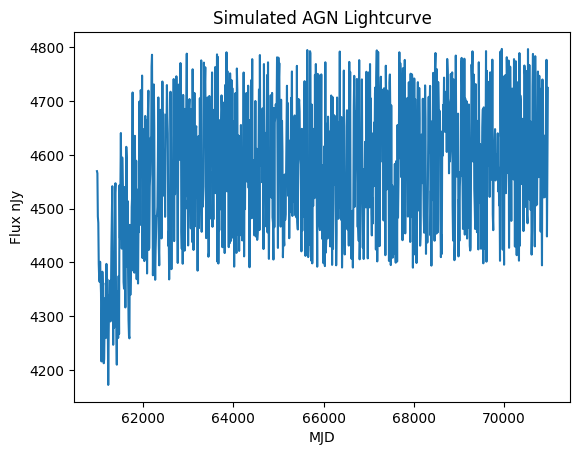

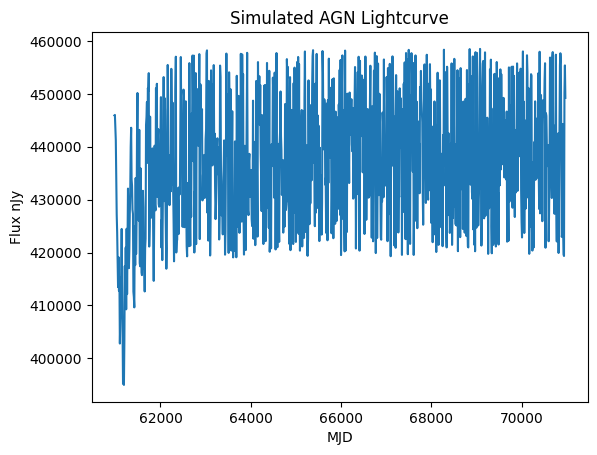

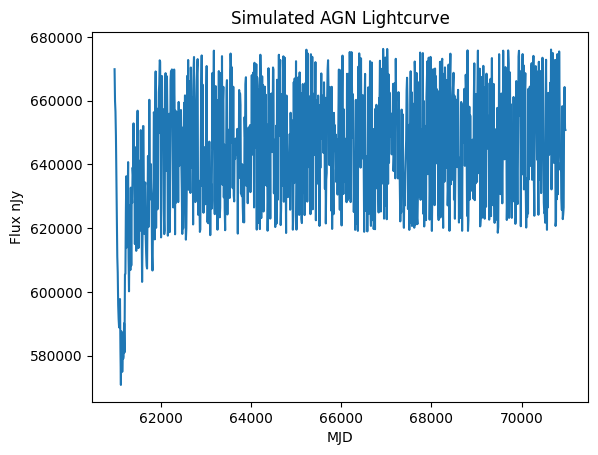

/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)

In [65]:
for i in range(n):
    lightcurve = ds.loc[i, "lightcurve"]
    if lightcurve is None or "flux_perfect" not in lightcurve.columns:
        print(f"Warning: Sample {i} has no lightcurve data or missing 'flux_perfect' column. Skipping.")
    sample_data = pd.DataFrame(lightcurve)[["mjd", "flux_perfect"]]
    x = sample_data.loc[:, "mjd"]
    y = sample_data.loc[:, "flux_perfect"] 
    model = ARIMA(y, order=(1, 0, 0), seasonal_order=(0, 0, 0, 0))
    model_fit = model.fit()
    predictions = model_fit.predict(start=0, end=len(x)-1)
    df = pd.concat([df, pd.DataFrame([model_fit.params])], ignore_index=True)

    if i <= 2:
        plt.plot(x, y)
        plt.xlabel("MJD")
        plt.ylabel("Flux nJy")
        plt.title("Simulated AGN Lightcurve")
        plt.show()

df.to_csv("arima_params.csv", index=False)

samples = []
for i in range(n):
    ar = df.loc[i+1, "ar.L1"]
    sigma = df.loc[i+1, "sigma2"]
    c = df.loc[i+1, "const"]
    param_dict = {"const": c, "ar.L1": ar, "sigma2": sigma}
    model = ARIMA([1], order=(1,0,0), seasonal_order=(0,0,0,0))
    with model.fix_params(param_dict):
        res = model.fit()
    samples = res.simulate(n_simulations=n_obs)
    for j in range(len(sample)):
        sample[j] = sample[j] 
    samples.append(sample)
    if i <= 2:
        plt.plot(x, sample)
        plt.xlabel("MJD")
        plt.ylabel("Flux nJy")
        plt.title("Simulated AGN Lightcurve")
        plt.show()


samples = pd.DataFrame(samples)

print(samples)

samples = pd.DataFrame(samples)

print(samples.head())
    
samples.to_csv("arima_samples.csv", index=False)